In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")
drop_col = [
    "Unnamed: 0",
    "track_id",
    "artists",
    "album_name",
    "track_name",
    "explicit",
    "track_genre"
]
df = df.drop(columns=drop_col)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
X, y = df.drop("popularity", axis=1), df.popularity
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [16]:
print(r2_score(y_test, pred))
print(root_mean_squared_error(y_test, pred))

0.02079225915422145
21.982272467064675


,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.239,22.305,0.000,17.000,35.000,50.000,100.000
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,212906.000,261506.000,5237295.000
danceability,114000.0,0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,114000.0,0.641,0.252,0.000,0.472,0.685,0.854,1.000
key,114000.0,5.309,3.560,0.000,2.000,5.000,8.000,11.000
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
mode,114000.0,0.638,0.481,0.000,0.000,1.000,1.000,1.000
speechiness,114000.0,0.085,0.106,0.000,0.036,0.049,0.084,0.965
acousticness,114000.0,0.315,0.333,0.000,0.017,0.169,0.598,0.996
instrumentalness,114000.0,0.156,0.310,0.000,0.000,0.000,0.049,1.000


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4
1,55,149610,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4
2,57,210826,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4


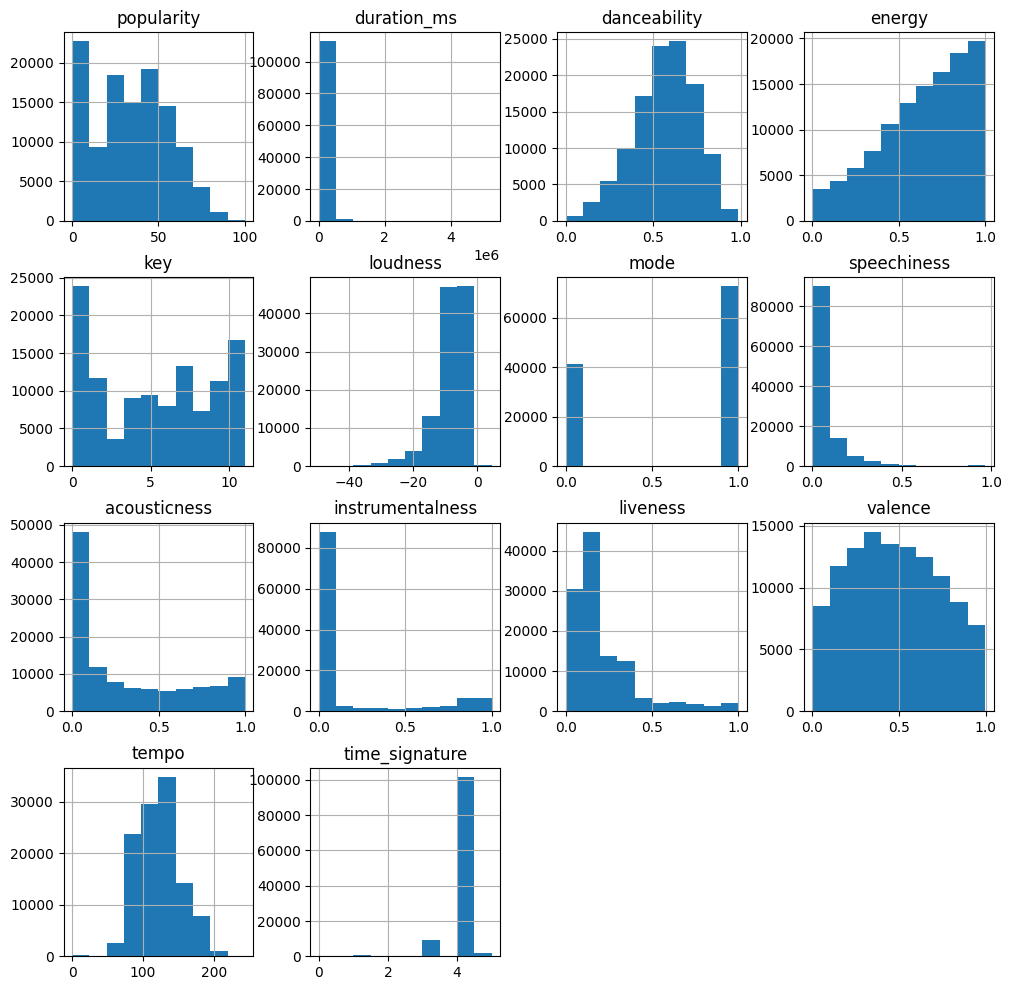

In [17]:
display(df.describe().round(3).T)
print("=" * 100)
display(df.head(3))
print("=" * 100)
df.hist(figsize=(12, 12))
plt.show()

In [18]:
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import plotly.graph_objects as go
import plotly.express as px

In [23]:
# @title
def draw_distr(x, title):
  fig = make_subplots(rows=1, cols=3, column_titles=[])
  fig.add_trace(
      go.Box(
          y=x,
          name=title,
          boxpoints="outliers"
      ),
      row=1, col=1
  )
  fig.add_trace(
      go.Histogram(
          x=x,
          name=title,
        ),
      row=1, col=2
  )

  density = gaussian_kde(x)
  x_vals = np.linspace(x.min(), x.max(), 100)
  y_vals = density(x_vals)

  fig.add_trace(
      go.Scatter(
          x=x_vals,
          y=y_vals,
          fill='tozeroy',
          name=title,
        ),
      row=1, col=3
  )
  fig.update_layout(height=400, width=1000, showlegend=True, title_text=title, title_font_size=26, title_x=0.5,)
  fig.show()